In [171]:
import torch
from torch import nn
import matplotlib.pyplot as plt

In [172]:
device = "cuda" if torch.cuda.is_available() else "cpu"

device

'cuda'

Data

In [173]:
weight = 0.3
bias = 0.9

start = 0
end = 1
step = 0.02

X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias


X[:10], y[:10]


(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.9000],
         [0.9060],
         [0.9120],
         [0.9180],
         [0.9240],
         [0.9300],
         [0.9360],
         [0.9420],
         [0.9480],
         [0.9540]]))

In [174]:
train_split = int(0.8 * len(X)) # 0.8 * 50 = 40

X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_train)


(40, 40, 10, 40)

In [175]:
def plot_predictions(train_data=X_train, train_label=y_train, test_data=X_test, test_label=y_test, predictions=None):

  plt.Figure(figsize=(10, 7))

  plt.scatter(train_data, train_label, c="b", s=4, label="Train Data")
  plt.scatter(test_data, test_label, c="r", s=4, label="Test Data")

  if predictions is not None:
    plt.scatter(test_data, predictions, c="g", s=4, label="Predictions")

  plt.legend(prop={"size": 14})

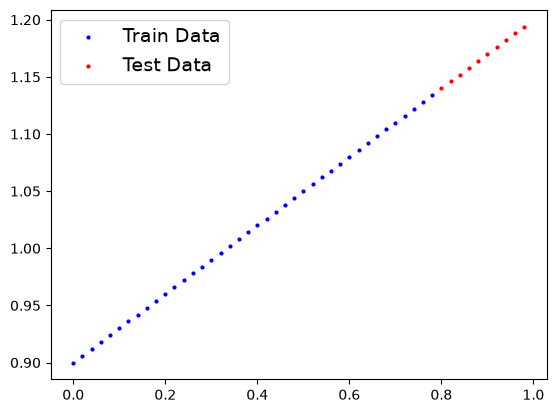

In [176]:
plot_predictions(X_train, y_train, X_test, y_test)

In [177]:
class LinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()

    self.linear_regression = nn.Linear(in_features=1, out_features=1, device=device)

  def forward(self, X: torch.Tensor) -> torch.Tensor:
    return self.linear_regression(X)

In [178]:
torch.manual_seed(42)

model = LinearRegressionModel()

model.state_dict()

OrderedDict([('linear_regression.weight', tensor([[0.2259]], device='cuda:0')),
             ('linear_regression.bias', tensor([0.9754], device='cuda:0'))])

In [179]:
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=0.01)

In [180]:
torch.manual_seed(42)

epochs = 300

epoch_count = []
train_loss_values = []
test_loss_values = []

X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)

for epoch in range(epochs):
  model.train()

  y_pred = model(X_train)

  loss = loss_fn(y_pred, y_train)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  model.eval()

  with torch.inference_mode():
    test_pred = model(X_test)

    test_loss = loss_fn(test_pred, y_test)
    
    if epoch % 20 == 0:
      epoch_count.append(epoch)
      train_loss_values.append(loss.detach().cpu().numpy())
      test_loss_values.append(test_loss.detach().cpu().numpy())
      print(f'Epochs: {epoch} | MAE Train Loss : {loss} | MAE Test Lost : {test_loss}')



Epochs: 0 | MAE Train Loss : 0.04654599353671074 | MAE Test Lost : 0.004874444101005793
Epochs: 20 | MAE Train Loss : 0.012014523148536682 | MAE Test Lost : 0.027200771495699883
Epochs: 40 | MAE Train Loss : 0.0051482501439750195 | MAE Test Lost : 0.011342930607497692
Epochs: 60 | MAE Train Loss : 0.010242223739624023 | MAE Test Lost : 0.00021883250155951828
Epochs: 80 | MAE Train Loss : 0.010242223739624023 | MAE Test Lost : 0.00021883250155951828
Epochs: 100 | MAE Train Loss : 0.010242223739624023 | MAE Test Lost : 0.00021883250155951828
Epochs: 120 | MAE Train Loss : 0.010242223739624023 | MAE Test Lost : 0.00021883250155951828
Epochs: 140 | MAE Train Loss : 0.010242223739624023 | MAE Test Lost : 0.00021883250155951828
Epochs: 160 | MAE Train Loss : 0.010242223739624023 | MAE Test Lost : 0.00021883250155951828
Epochs: 180 | MAE Train Loss : 0.010242223739624023 | MAE Test Lost : 0.00021883250155951828
Epochs: 200 | MAE Train Loss : 0.010242223739624023 | MAE Test Lost : 0.0002188325

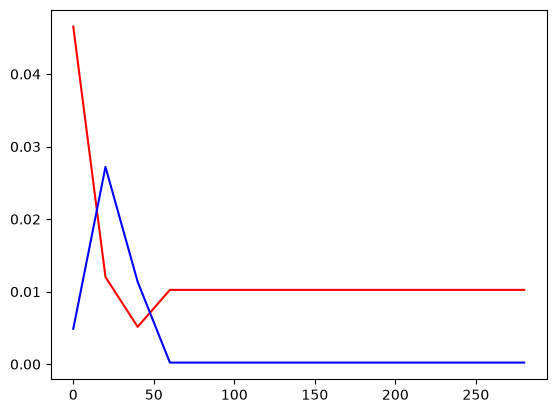

In [181]:
plt.plot(epoch_count, train_loss_values, c="r")
plt.plot(epoch_count, test_loss_values, c="b")
plt.show()


In [182]:
model.state_dict()

OrderedDict([('linear_regression.weight', tensor([[0.2931]], device='cuda:0')),
             ('linear_regression.bias', tensor([0.8924], device='cuda:0'))])

In [183]:
with torch.inference_mode():
  y_preds = model(X_test)

y_preds

tensor([[1.1269],
        [1.1328],
        [1.1387],
        [1.1445],
        [1.1504],
        [1.1563],
        [1.1621],
        [1.1680],
        [1.1738],
        [1.1797]], device='cuda:0')

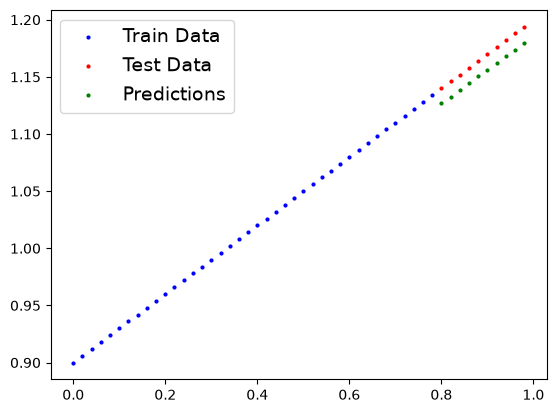

In [184]:
plot_predictions(predictions=y_preds.detach().cpu().numpy())

Save And Load

In [186]:
from pathlib import Path

MODEL_PATH = Path("models")
MODEL_PATH.mkdir(exist_ok=True, parents=True)

MODEL_NAME = "01_exercises_workflow_model.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

torch.save(obj=model.state_dict(), f=MODEL_SAVE_PATH)

In [188]:
loaded_model = LinearRegressionModel()

loaded_model.load_state_dict(torch.load(MODEL_SAVE_PATH))

loaded_model.to(device)

print(f"Loaded model:\n{loaded_model}")
print(f"Model on device:\n{next(loaded_model.parameters()).device}")

Loaded model:
LinearRegressionModel(
  (linear_regression): Linear(in_features=1, out_features=1, bias=True)
)
Model on device:
cuda:0


In [189]:
loaded_model.eval()

with torch.inference_mode():
  loaded_model_pred = loaded_model(X_test)

y_preds == loaded_model_pred

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]], device='cuda:0')